In [ ]:
# Install required library for interactive sliders
!pip install ipywidgets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.3 MB/s eta 0:00:00


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython import display

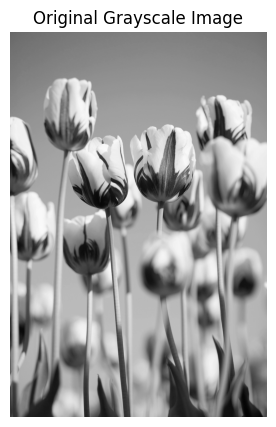

Image Shape  (5760, 3840)


In [ ]:
img = cv2.imread('/content/lab03.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6, 5))
plt.imshow(img_gray , cmap = 'gray')
plt.title('Original Grayscale Image')
plt.axis('off')
plt.show()

print("Image Shape ", img_gray.shape)


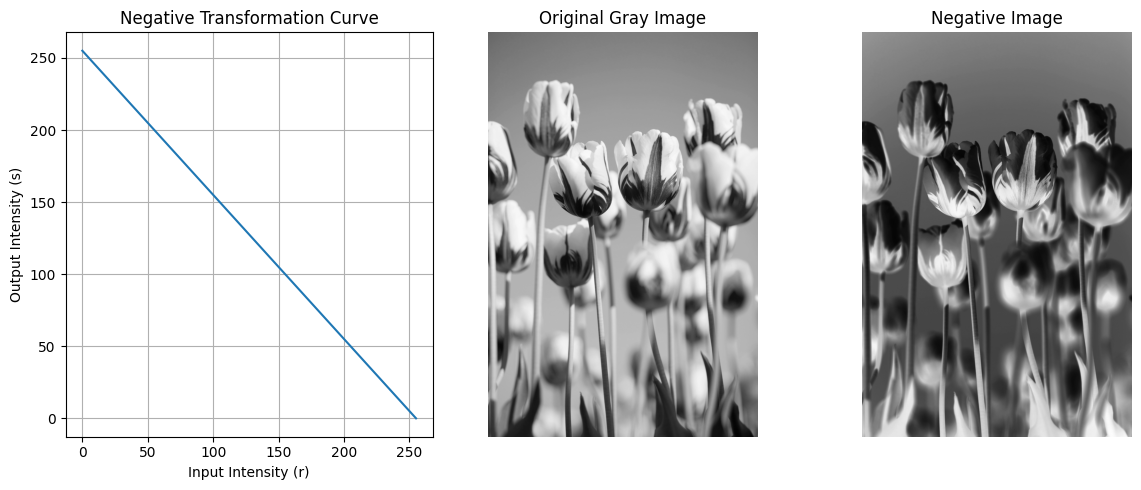

In [ ]:


img_gray = cv2.imread('/content/lab03.jpg', cv2.IMREAD_GRAYSCALE)

r = np.arange(256)

s = 255 - r

negative = 255 - img_gray

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.plot(r, s)
plt.title("Negative Transformation Curve")
plt.xlabel("Input Intensity (r)")
plt.ylabel("Output Intensity (s)")
plt.grid()

plt.subplot(1, 3, 2)
plt.imshow(img_gray, cmap='gray')
plt.title("Original Gray Image")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(negative, cmap='gray')
plt.title("Negative Image")
plt.axis('off')

plt.tight_layout()
plt.show()

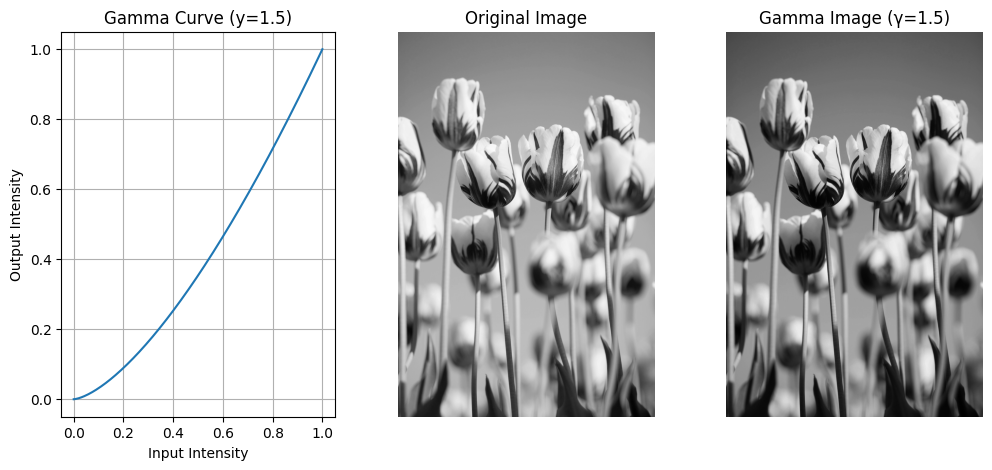

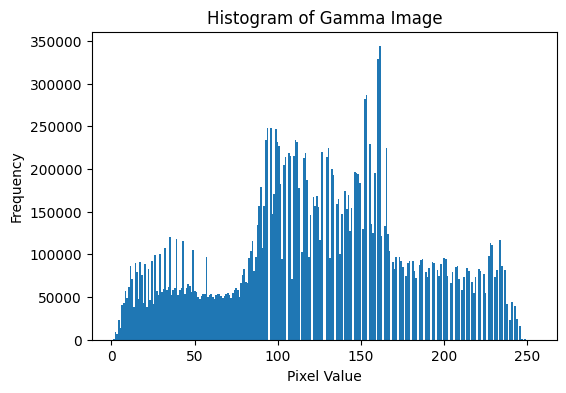

In [ ]:

gamma = 1.5

normalized = img_gray / 255.0

gamma_img = np.power(normalized, gamma)
gamma_img = np.uint8(gamma_img * 255)

r = np.linspace(0, 1, 256)
s = np.power(r, gamma)

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.plot(r, s)
plt.title(f"Gamma Curve (y={gamma})")
plt.xlabel("Input Intensity")
plt.ylabel("Output Intensity")
plt.grid()

plt.subplot(1,3,2)
plt.imshow(img_gray, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(gamma_img, cmap='gray')
plt.title(f"Gamma Image (γ={gamma})")
plt.axis('off')

plt.show()

plt.figure(figsize=(6,4))
plt.hist(gamma_img.ravel(), bins=256)
plt.title("Histogram of Gamma Image")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

gamma_slider = widgets.FloatSlider(
    value=1.0,
    min=0.1,
    max=2.0,
    step=0.1,
    description='Gamma:',
)



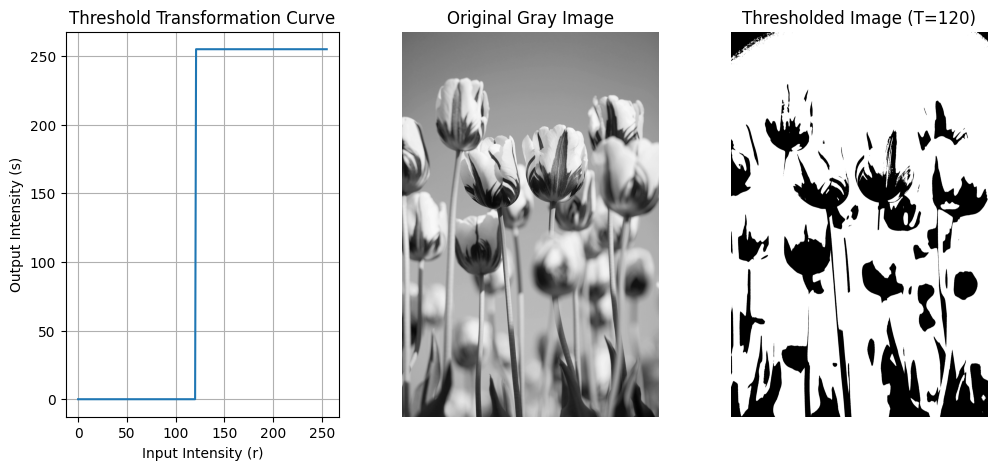

In [ ]:


threshold_value = 120

def threshold_image(thresh):
    _, thresholded = cv2.threshold(img_gray, thresh, 255, cv2.THRESH_BINARY)
    return thresholded

thresholded_img = threshold_image(threshold_value)

r = np.arange(256)
s = np.where(r > threshold_value, 255, 0)

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.plot(r, s)
plt.title("Threshold Transformation Curve")
plt.xlabel("Input Intensity (r)")
plt.ylabel("Output Intensity (s)")
plt.grid()

plt.subplot(1,3,2)
plt.imshow(img_gray, cmap='gray')
plt.title("Original Gray Image")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(thresholded_img, cmap='gray')
plt.title(f"Thresholded Image (T={threshold_value})")
plt.axis('off')

plt.show()



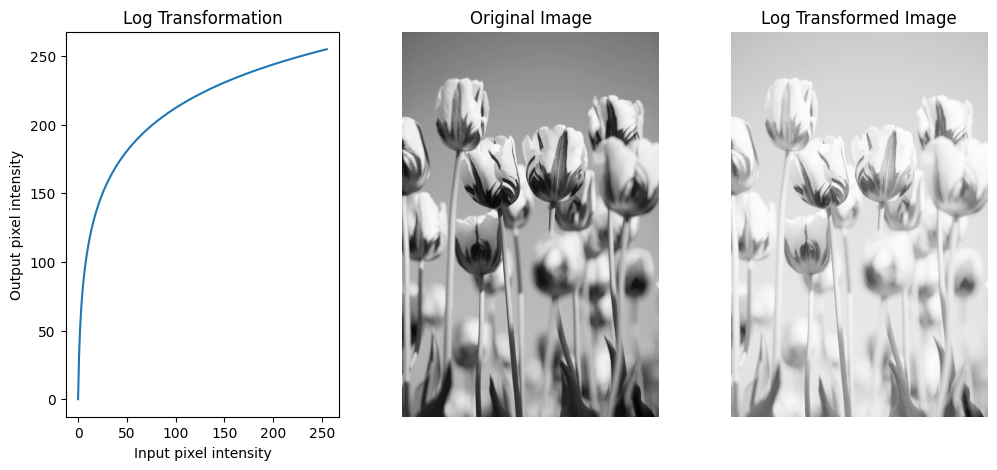

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Load the grayscale image if not already defined
img_gray = cv2.imread('/lab03.jpg', cv2.IMREAD_GRAYSCALE)

# Check if the image was loaded successfully
if img_gray is None:
    print("Error: Could not load the image. Please check the path and ensure the file exists.")
else:
    # Convert image to float
    img_float = img_gray.astype(np.float32)

    # create input intensity values
    r = np.linspace(0, 255, 256)

    # compute scaling constant
    c = 255 / np.log(1 + 255)

    # log curve
    s = c * np.log(1 + r)

    # Apply log transformation to image
    log_transformed = c * np.log(1 + img_float)

    # Clip values to 0–255 before converting
    log_transformed = np.clip(log_transformed, 0, 255)
    log_transformed = np.uint8(log_transformed)

    # plot
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 3, 1)
    plt.plot(r, s)
    plt.title('Log Transformation')
    plt.xlabel('Input pixel intensity')
    plt.ylabel('Output pixel intensity')
    plt.grid(False)

    plt.subplot(1, 3, 2)
    plt.imshow(img_gray, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(log_transformed, cmap='gray')
    plt.title('Log Transformed Image')
    plt.axis('off')

    plt.show()

(np.float64(-0.5), np.float64(3839.5), np.float64(5759.5), np.float64(-0.5))

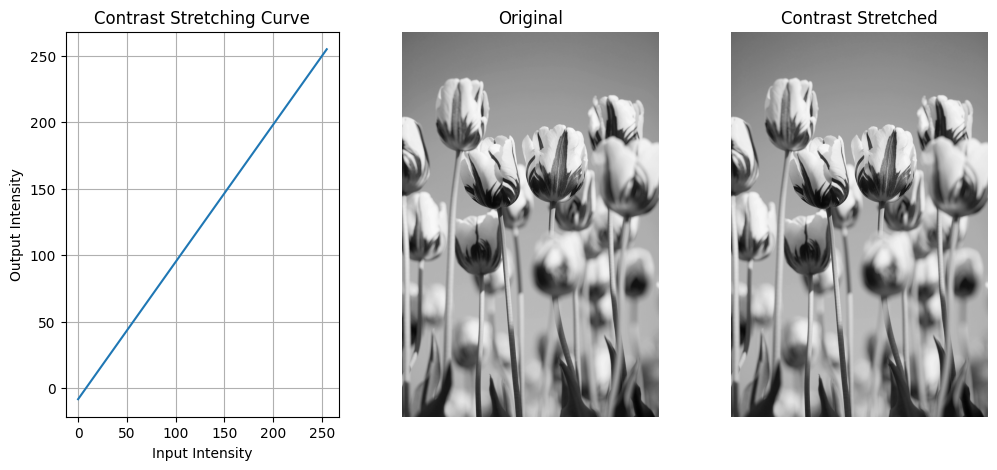

In [29]:
#get min and max intensity
r_min = np.min(img_gray)
r_max = np.max(img_gray)

# Apply contrast stretching

contrast_img = (img_gray - r_min) * (255 / (r_max - r_min))

contrast_img = np.uint8(contrast_img)

# Curve

r = np.linspace(0, 255, 256)

s = (r - r_min) * (255 / (r_max - r_min))

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)

plt.plot(r, s)
plt.title("Contrast Stretching Curve")
plt.xlabel("Input Intensity")
plt.ylabel("Output Intensity")

plt.grid()

plt.subplot(1,3,2)

plt.imshow(img_gray, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(contrast_img, cmap='gray')
plt.title("Contrast Stretched")
plt.axis('off')